In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('train.csv')
##filter out cats
df = df[df['Type'] == 1]
##filter quantity to 1
df = df[df['Quantity'] == 1]
##Drop na
df = df.dropna()
##Drop columns
X = df.drop(columns=['RescuerID', 'Description','PetID','Name','AdoptionSpeed'])
y = df['AdoptionSpeed']

##encode categorical data
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = pd.DataFrame(encoder.fit_transform(X[['Type', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State']]), columns=encoder.get_feature_names_out(['Type', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State']))

##concatenate encoded data with numerical data
X_numeric = X.select_dtypes(include=['int64', 'float64']).reset_index(drop=True)
X_encoded = X_encoded.reset_index(drop=True)
X_transformed = pd.concat([X_numeric, X_encoded], axis=1)

##split into train test sets
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.25)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale numeric features
scaler = StandardScaler()
X_numeric_scaled = pd.DataFrame(scaler.fit_transform(X_numeric), columns=X_numeric.columns)

# Concatenate scaled numeric features with the encoded features
X_transformed = pd.concat([X_numeric_scaled, X_encoded], axis=1)


In [8]:
#fit logistic regression model
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the parameter grid to search over
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # Regularization strength
    'solver': ['liblinear', 'saga'],  # Solvers that work for small datasets or large datasets
    'max_iter': [100, 200, 300]  # Number of iterations for convergence
}

# Initialize the Logistic Regression model
model = LogisticRegression(random_state=42)

# Initialize GridSearchCV with cross-validation
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

# Fit the model to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and the best score
print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-validation Score:", grid_search.best_score_)

# Use the best model from GridSearchCV
best_model = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred = best_model.predict(X_test)

# Evaluate the performance
from sklearn.metrics import classification_report, confusion_matrix
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Hyperparameters: {'C': 1, 'max_iter': 100, 'solver': 'liblinear'}
Best Cross-validation Score: 0.3736669866081631
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        36
           1       0.34      0.15      0.20       296
           2       0.34      0.43      0.38       421
           3       0.35      0.14      0.20       393
           4       0.41      0.72      0.52       414

    accuracy                           0.37      1560
   macro avg       0.29      0.29      0.26      1560
weighted avg       0.35      0.37      0.33      1560

Confusion Matrix:
[[  0   5  10   8  13]
 [  0  43 130  30  93]
 [  0  36 183  31 171]
 [  0  31 147  54 161]
 [  0  10  74  31 299]]


c:\Users\KoltenSmith\anaconda3\envs\classes24\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\KoltenSmith\anaconda3\envs\classes24\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\KoltenSmith\anaconda3\envs\classes24\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [9]:
##Fit Random Forest model
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid to search over
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

# Initialize GridSearchCV with cross-validation
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, cv=5, n_jobs=-1, verbose=1)

# Fit the model to the training data
grid_search_rf.fit(X_train, y_train)

# Print the best parameters and the best score
print("Best Hyperparameters for Random Forest:", grid_search_rf.best_params_)
print("Best Cross-validation Score:", grid_search_rf.best_score_)

# Use the best model from GridSearchCV
best_rf_model = grid_search_rf.best_estimator_

# Make predictions on the test set using the best model
y_pred_rf_best = best_rf_model.predict(X_test)

# Evaluate the performance
print("Random Forest (Tuned) - Classification Report:")
print(classification_report(y_test, y_pred_rf_best))

print("Random Forest (Tuned) - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_best))


Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Hyperparameters for Random Forest: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-validation Score: 0.4330981763334704
Random Forest (Tuned) - Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        36
           1       0.41      0.29      0.34       296
           2       0.36      0.48      0.41       421
           3       0.44      0.27      0.34       393
           4       0.52      0.69      0.59       414

    accuracy                           0.44      1560
   macro avg       0.35      0.35      0.34      1560
weighted avg       0.42      0.44      0.42      1560

Random Forest (Tuned) - Confusion Matrix:
[[  0  12   8   6  10]
 [  0  85 137  33  41]
 [  1  52 202  67  99]
 [  0  42 131 108 112]
 [  0  18  77  34 285]]


In [11]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search over
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# Initialize the XGBoost classifier
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

# Initialize GridSearchCV with cross-validation
grid_search_xgb = GridSearchCV(estimator=xgb_model, param_grid=param_grid_xgb, cv=5, n_jobs=-1, verbose=1)

# Fit the model to the training data
grid_search_xgb.fit(X_train, y_train)

# Print the best parameters and the best score
print("Best Hyperparameters for XGBoost:", grid_search_xgb.best_params_)
print("Best Cross-validation Score:", grid_search_xgb.best_score_)

# Use the best model from GridSearchCV
best_xgb_model = grid_search_xgb.best_estimator_

# Make predictions on the test set using the best model
y_pred_xgb_best = best_xgb_model.predict(X_test)

# Evaluate the performance
print("XGBoost (Tuned) - Classification Report:")
print(classification_report(y_test, y_pred_xgb_best))

print("XGBoost (Tuned) - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_best))


Fitting 5 folds for each of 243 candidates, totalling 1215 fits


c:\Users\KoltenSmith\anaconda3\envs\classes24\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:47:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Hyperparameters for XGBoost: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.7}
Best Cross-validation Score: 0.42967914438502675
XGBoost (Tuned) - Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        36
           1       0.41      0.27      0.32       296
           2       0.35      0.48      0.41       421
           3       0.43      0.24      0.31       393
           4       0.52      0.71      0.60       414

    accuracy                           0.43      1560
   macro avg       0.34      0.34      0.33      1560
weighted avg       0.42      0.43      0.41      1560

XGBoost (Tuned) - Confusion Matrix:
[[  0  13   8   4  11]
 [  0  79 146  32  39]
 [  0  52 203  62 104]
 [  0  35 146  94 118]
 [  0  16  74  28 296]]


c:\Users\KoltenSmith\anaconda3\envs\classes24\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\KoltenSmith\anaconda3\envs\classes24\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\KoltenSmith\anaconda3\envs\classes24\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search over
param_grid_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2'],
    'criterion': ['gini', 'entropy']
}

# Initialize the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV with cross-validation
grid_search_dt = GridSearchCV(estimator=dt_model, param_grid=param_grid_dt, cv=5, n_jobs=-1, verbose=1)

# Fit the model to the training data
grid_search_dt.fit(X_train, y_train)

# Print the best parameters and the best score
print("Best Hyperparameters for Decision Tree:", grid_search_dt.best_params_)
print("Best Cross-validation Score:", grid_search_dt.best_score_)

# Use the best model from GridSearchCV
best_dt_model = grid_search_dt.best_estimator_

# Make predictions on the test set using the best model
y_pred_dt_best = best_dt_model.predict(X_test)

# Evaluate the performance
print("Decision Tree (Tuned) - Classification Report:")
print(classification_report(y_test, y_pred_dt_best))

print("Decision Tree (Tuned) - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_best))


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Hyperparameters for Decision Tree: {'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best Cross-validation Score: 0.4044515288632936
Decision Tree (Tuned) - Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        36
           1       0.35      0.33      0.34       296
           2       0.35      0.44      0.39       421
           3       0.43      0.17      0.25       393
           4       0.49      0.71      0.58       414

    accuracy                           0.41      1560
   macro avg       0.33      0.33      0.31      1560
weighted avg       0.40      0.41      0.39      1560

Decision Tree (Tuned) - Confusion Matrix:
[[  0  15   7   3  11]
 [  0  97 135  20  44]
 [  0  75 186  51 109]
 [  0  63 123  68 139]
 [  0  30  74  15 295]]


c:\Users\KoltenSmith\anaconda3\envs\classes24\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\KoltenSmith\anaconda3\envs\classes24\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\KoltenSmith\anaconda3\envs\classes24\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

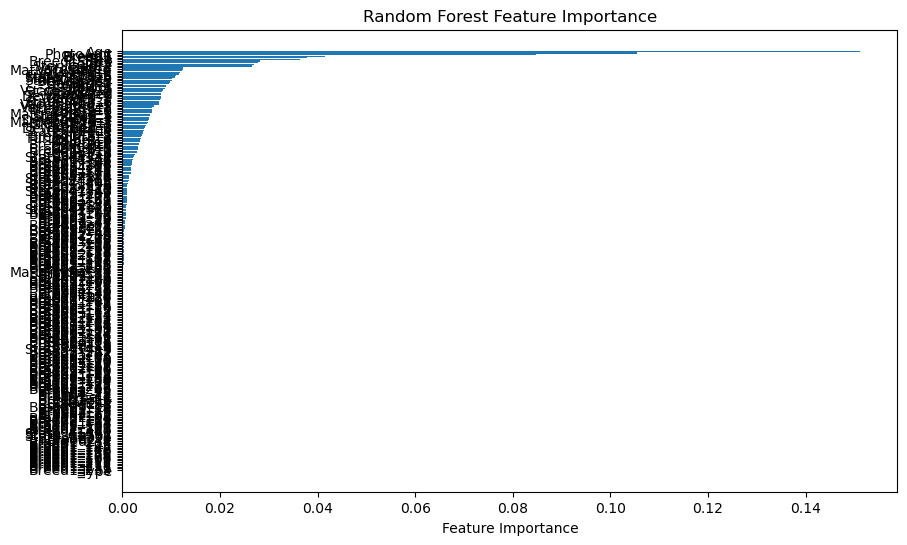

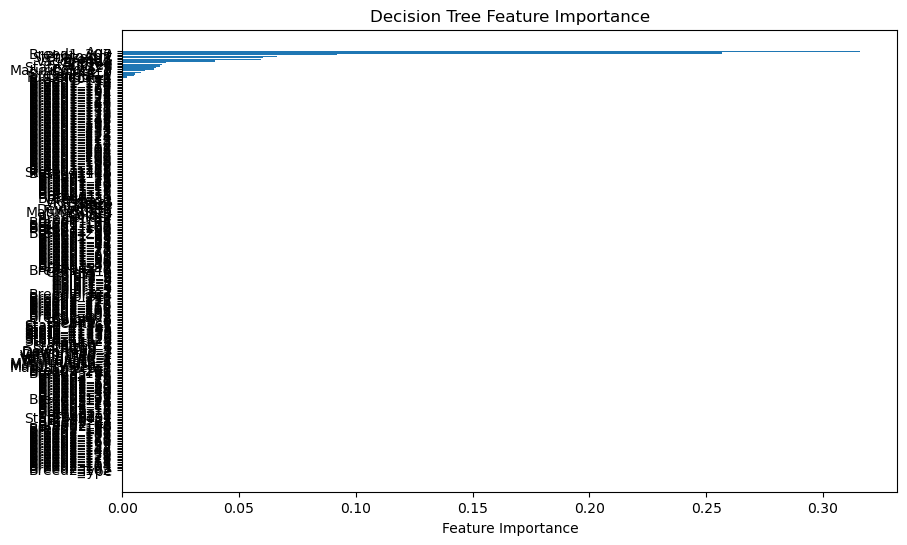

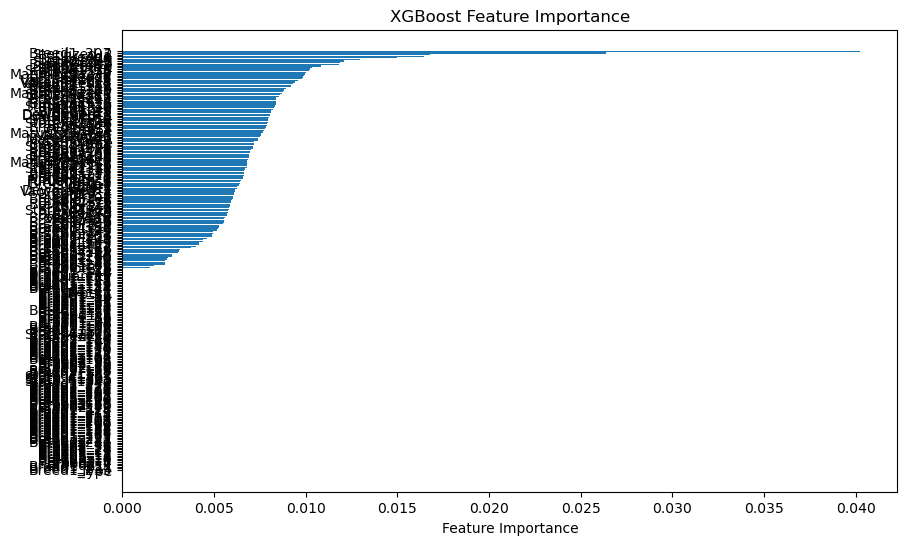

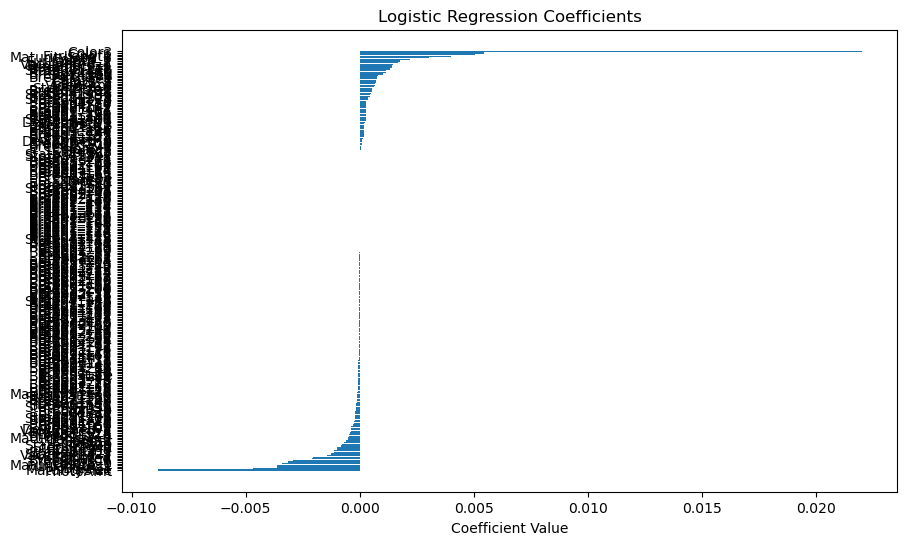

In [19]:
# Feature importance from Random Forest model
importances_rf = best_rf_model.feature_importances_

# Sort the importances
sorted_idx_rf = importances_rf.argsort()

# Plot the feature importances
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(X_train.columns[sorted_idx_rf], importances_rf[sorted_idx_rf])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.show()

# Feature importance from Decision Tree model
importances_dt = best_dt_model.feature_importances_

# Sort the importances
sorted_idx_dt = importances_dt.argsort()

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(X_train.columns[sorted_idx_dt], importances_dt[sorted_idx_dt])
plt.xlabel('Feature Importance')
plt.title('Decision Tree Feature Importance')
plt.show()

# Feature importance from XGBoost model
importances_xgb = best_xgb_model.feature_importances_

# Sort the importances
sorted_idx_xgb = importances_xgb.argsort()

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(X_train.columns[sorted_idx_xgb], importances_xgb[sorted_idx_xgb])
plt.xlabel('Feature Importance')
plt.title('XGBoost Feature Importance')
plt.show()

# Get the coefficients from the Logistic Regression model
coefficients_lr = best_model.coef_[0]

# Sort the coefficients
sorted_idx_lr = coefficients_lr.argsort()

# Plot the coefficients
plt.figure(figsize=(10, 6))
plt.barh(X_train.columns[sorted_idx_lr], coefficients_lr[sorted_idx_lr])
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression Coefficients')
plt.show()


In [21]:
##Show the most important features in the RF
importances_rf = best_rf_model.feature_importances_
importances_rf = importances_rf / importances_rf.sum()  # Normalize the importances
indices_rf = importances_rf.argsort()[::-1]  # Sort the indices in descending order
print("Feature ranking (Random Forest):")
for f in range(X_train.shape[1]):
    print(f"{f + 1}. feature {X_train.columns[indices_rf[f]]} ({importances_rf[indices_rf[f]]:.4f})")

Feature ranking (Random Forest):
1. feature Age (0.1512)
2. feature PhotoAmt (0.1055)
3. feature Breed1 (0.0848)
4. feature Breed2 (0.0415)
5. feature Fee (0.0378)
6. feature Breed1_307 (0.0363)
7. feature State (0.0283)
8. feature Color1 (0.0278)
9. feature Sterilized_2 (0.0269)
10. feature Color2 (0.0266)
11. feature Vaccinated (0.0124)
12. feature MaturitySize_2 (0.0123)
13. feature Color1_2 (0.0122)
14. feature FurLength (0.0119)
15. feature FurLength_2 (0.0116)
16. feature State_41326 (0.0111)
17. feature MaturitySize (0.0109)
18. feature State_41327 (0.0102)
19. feature Dewormed (0.0101)
20. feature Gender_2 (0.0097)
21. feature Color2_2 (0.0096)
22. feature Gender (0.0089)
23. feature Color3 (0.0089)
24. feature Vaccinated_2 (0.0087)
25. feature State_41330 (0.0083)
26. feature VideoAmt (0.0082)
27. feature Sterilized (0.0079)
28. feature Dewormed_2 (0.0079)
29. feature Gender_1 (0.0078)
30. feature Color1_5 (0.0078)
31. feature FurLength_1 (0.0077)
32. feature State_41336 (0.00

c:\Users\KoltenSmith\anaconda3\envs\classes24\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\KoltenSmith\anaconda3\envs\classes24\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\KoltenSmith\anaconda3\envs\classes24\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

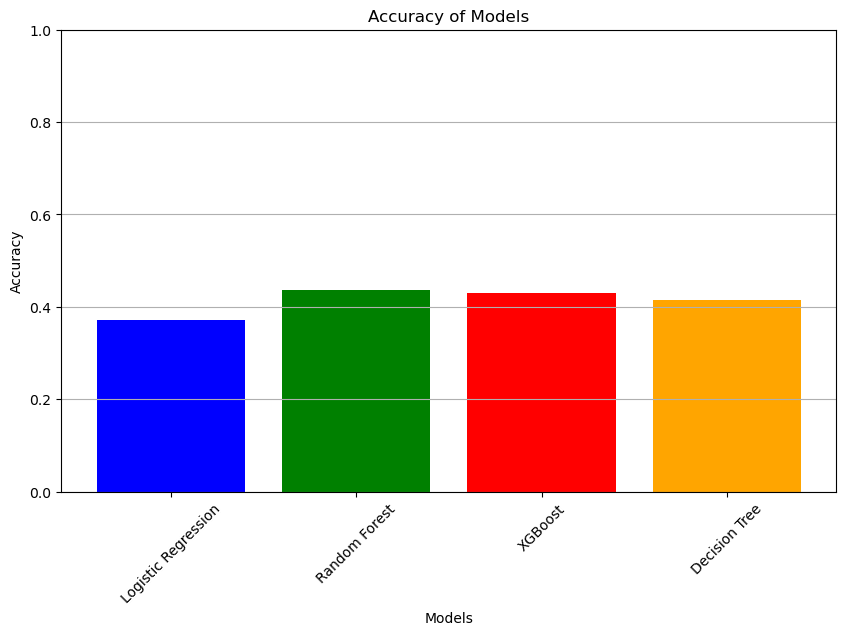

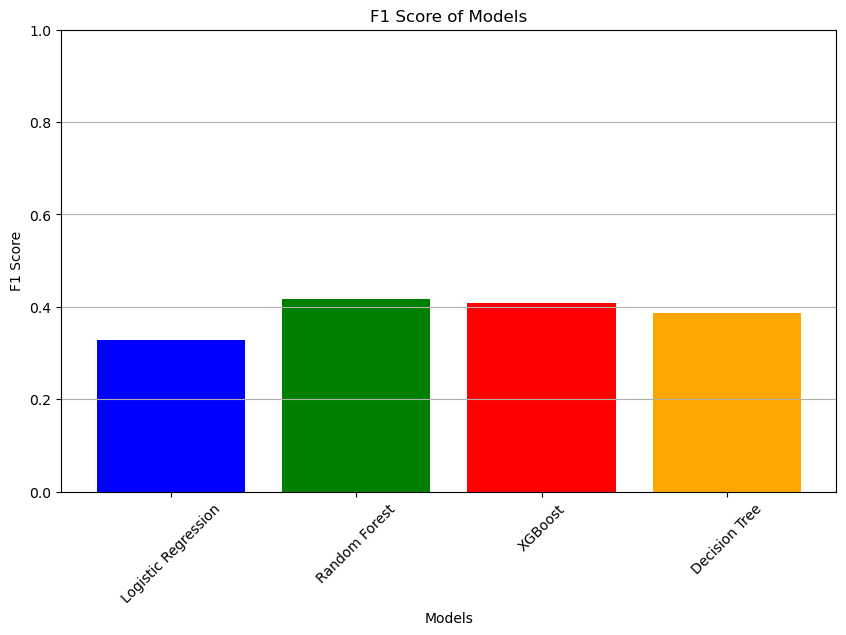

In [ ]:
#compare the logistic regression, random forest, xgboost and decision tree models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
import numpy as np
##plot the best models against eachother
models = ['Logistic Regression', 'Random Forest', 'XGBoost', 'Decision Tree']
scores = [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_rf_best), accuracy_score(y_test, y_pred_xgb_best), accuracy_score(y_test, y_pred_dt_best)]
f1_scores = [f1_score(y_test, y_pred, average='weighted'), f1_score(y_test, y_pred_rf_best, average='weighted'), f1_score(y_test, y_pred_xgb_best, average='weighted'), f1_score(y_test, y_pred_dt_best, average='weighted')]
precision_scores = [precision_score(y_test, y_pred, average='weighted'), precision_score(y_test, y_pred_rf_best, average='weighted'), precision_score(y_test, y_pred_xgb_best, average='weighted'), precision_score(y_test, y_pred_dt_best, average='weighted')]
recall_scores = [recall_score(y_test, y_pred, average='weighted'), recall_score(y_test, y_pred_rf_best, average='weighted'), recall_score(y_test, y_pred_xgb_best, average='weighted'), recall_score(y_test, y_pred_dt_best, average='weighted')]

#plot the scores
plt.figure(figsize=(10, 6))
plt.bar(models, scores, color=['blue', 'green', 'red', 'orange'])
plt.title('Accuracy of Models')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()
#plot the f1 scores
plt.figure(figsize=(10, 6))
plt.bar(models, f1_scores, color=['blue', 'green', 'red', 'orange'])
plt.title('F1 Score of Models')
plt.xlabel('Models')
plt.ylabel('F1 Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()





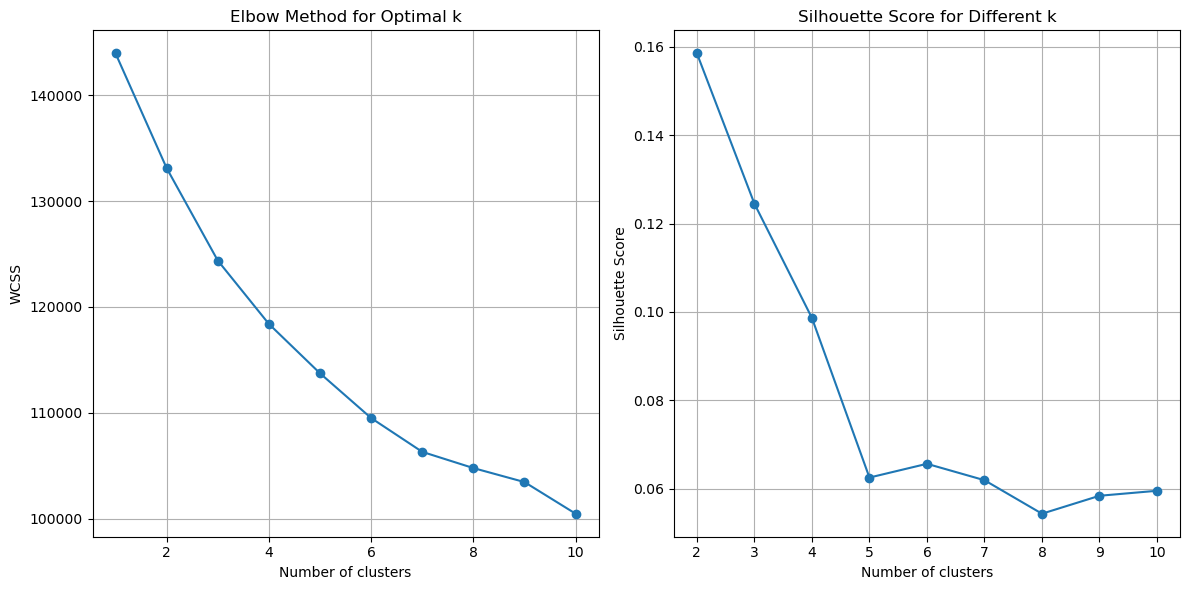

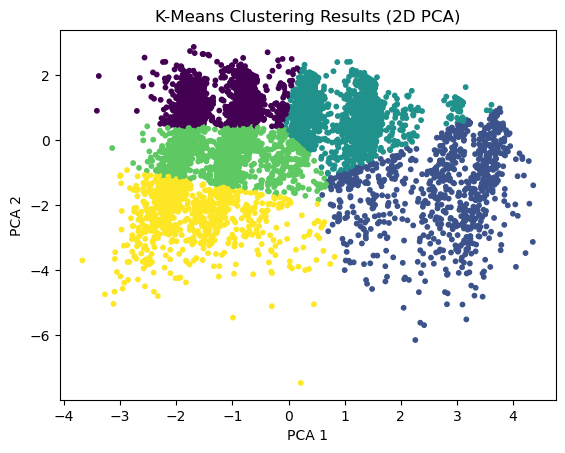

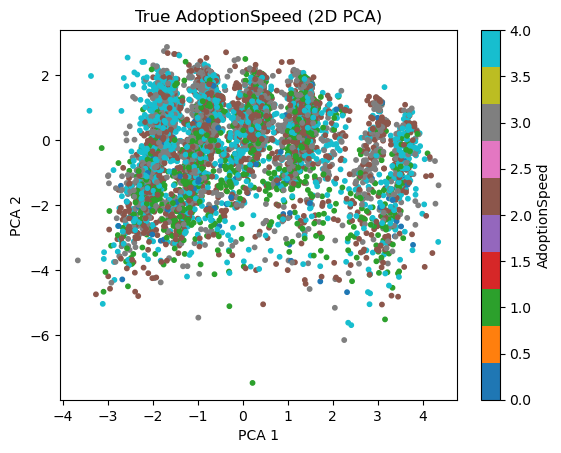

In [36]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Optional: Reduce dimensionality for clustering speed
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_transformed)

silhouette = []
# Try different numbers of clusters and evaluate
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_pca)
    silhouette_avg = silhouette_score(X_pca, cluster_labels)
    silhouette.append(silhouette_avg)
## try different numbers of clusters and evaluate wcss and silhouette score
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)
#plot wcss and silhouette score
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette, marker='o')
plt.title('Silhouette Score for Different k')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.grid()
plt.tight_layout()
plt.show()

##lets use k=5
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_transformed)

kmeans = KMeans(n_clusters=5)
labels = kmeans.fit_predict(X_2d)
## Plot the clusters in 2D
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis', s=10)
plt.title('K-Means Clustering Results (2D PCA)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab10', s=10)
plt.title('True AdoptionSpeed (2D PCA)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='AdoptionSpeed')
plt.show()


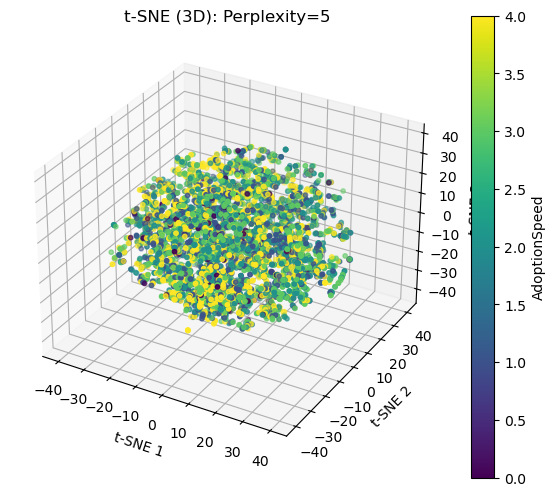

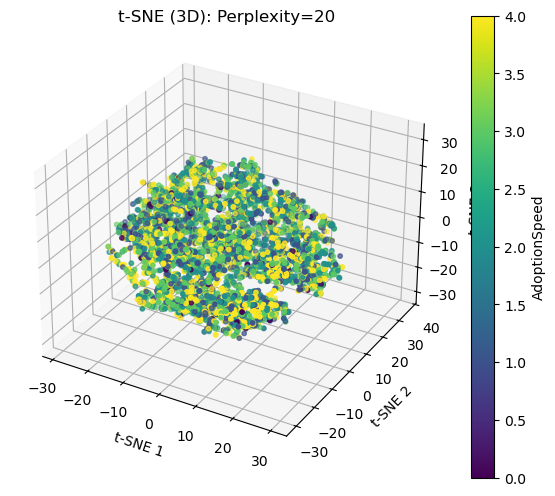

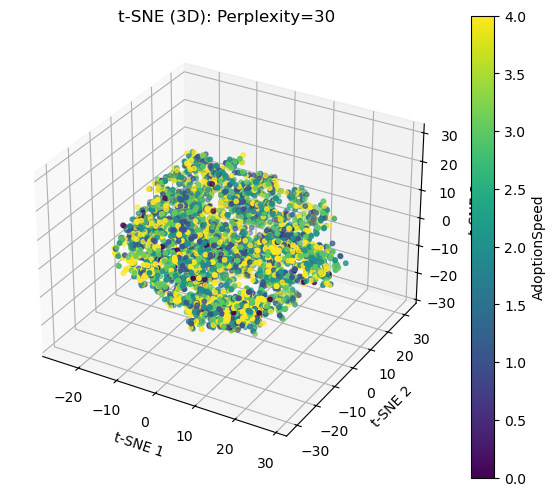

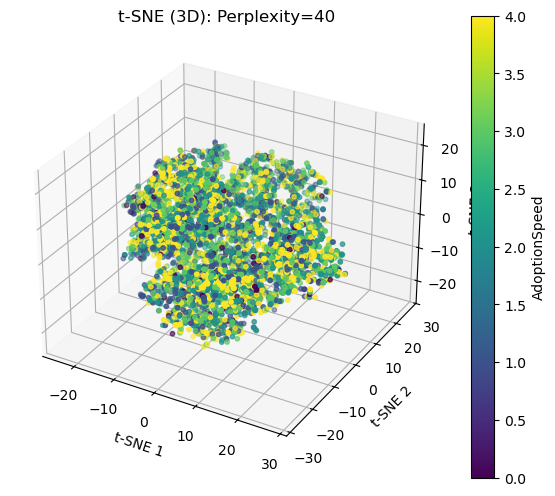

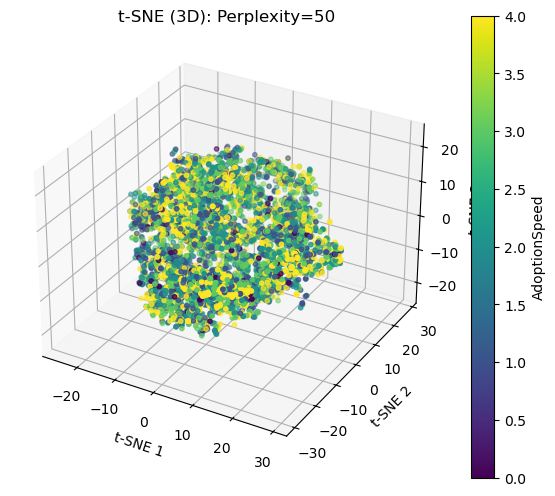

In [39]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D projection
import seaborn as sns
from sklearn.manifold import TSNE

def try_tsne(perplexity, n_components):
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=42)
    X_tsne = tsne.fit_transform(X_transformed)

    if n_components == 3:
        fig = plt.figure(figsize=(7, 6))
        ax = fig.add_subplot(111, projection='3d')
        scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2],
                             c=y, cmap='viridis', s=10)
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")
        ax.set_zlabel("t-SNE 3")
        plt.title(f't-SNE (3D): Perplexity={perplexity}')
        plt.colorbar(scatter, label='AdoptionSpeed')
        plt.show()
    else:
        plt.figure(figsize=(6, 5))
        sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='viridis', s=10, legend='full')
        plt.title(f't-SNE: Perplexity={perplexity}, Components={n_components}')
        plt.xlabel("t-SNE 1")
        plt.ylabel("t-SNE 2")
        plt.legend(title='AdoptionSpeed', loc='best')
        plt.show()

# Try different perplexities (3D only example)
for p in [5, 20, 30, 40, 50]:
    try_tsne(perplexity=p, n_components=3)





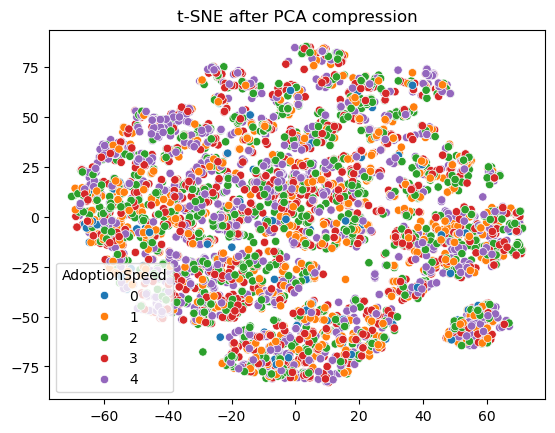

In [33]:
##Try encoding to see if that helps:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_transformed)

from sklearn.manifold import TSNE
X_tsne = TSNE(n_components=2).fit_transform(X_pca)

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='tab10')
plt.title("t-SNE after PCA compression")
plt.show()


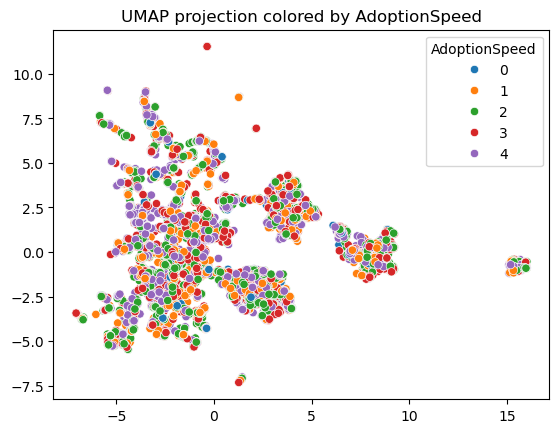

In [32]:
import umap
reducer = umap.UMAP()
X_umap = reducer.fit_transform(X_transformed)

sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=y, palette='tab10')
plt.title("UMAP projection colored by AdoptionSpeed")
plt.show()


Epoch 1/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2071
Epoch 2/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0786
Epoch 3/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0653
Epoch 4/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0560
Epoch 5/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0513
Epoch 6/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0479
Epoch 7/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0476
Epoch 8/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0458
Epoch 9/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0444
Epoch 10/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0434
Epoch 11/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0420
Epoch 12/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0418
Epoch 13/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0415
Epoch 14/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0407
Epoch 15/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

Text(0.5, 1.0, 'Reconstruction Error by Adoption Speed')

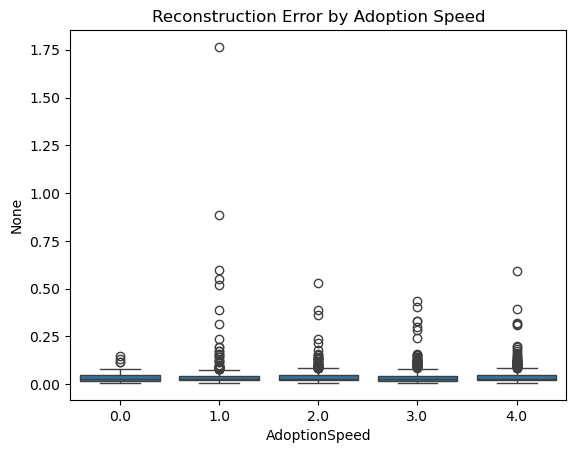

In [31]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import regularizers

input_dim = X_transformed.shape[1]
encoding_dim = 20

input_layer = Input(shape=(input_dim,))
encoder = Dense(encoding_dim, activation="relu")(input_layer)
decoder = Dense(input_dim, activation="sigmoid")(encoder)

autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_transformed, X_transformed, epochs=20, batch_size=32, shuffle=True, verbose=1)

reconstructions = autoencoder.predict(X_transformed)
mse = np.mean((X_transformed - reconstructions)**2, axis=1)
sns.boxplot(x=y, y=mse)
plt.title("Reconstruction Error by Adoption Speed")



               Age          Fee     VideoAmt     PhotoAmt
count  6238.000000  6238.000000  6238.000000  6238.000000
mean     14.503687    27.519397     0.052100     3.490702
std      22.571403    90.737462     0.313776     3.095688
min       0.000000     0.000000     0.000000     0.000000
25%       2.000000     0.000000     0.000000     1.000000
50%       4.000000     0.000000     0.000000     3.000000
75%      17.000000     0.000000     0.000000     5.000000
max     255.000000  2000.000000     6.000000    30.000000
Breed1
307    4343
141     167
205     164
179     153
218     138
       ... 
93        1
25        1
154       1
192       1
81        1
Name: count, Length: 108, dtype: int64
Breed2
0      4332
307    1270
218      79
141      57
103      47
       ... 
25        1
111       1
4         1
36        1
5         1
Name: count, Length: 78, dtype: int64
Gender
2    3607
1    2631
Name: count, dtype: int64
Color1
1    2788
2    2137
5     498
7     312
3     294
4     129
6  

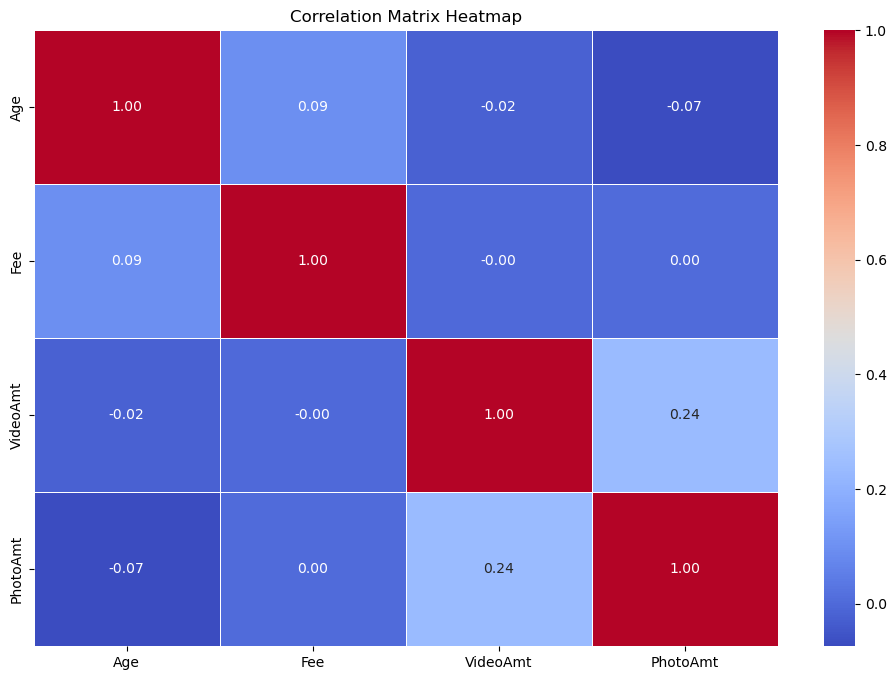

In [6]:
df = pd.read_csv('train.csv')
##filter out cats
df = df[df['Type'] == 1]
##filter quantity to 1
df = df[df['Quantity'] == 1]
##Drop na
df = df.dropna()
##Drop columns
X = df.drop(columns=['RescuerID', 'Description','PetID','Name','AdoptionSpeed', 'Type', 'Quantity'])
y = df['AdoptionSpeed']
X_numeric = df.drop(columns=['RescuerID', 'Description','PetID','Name','AdoptionSpeed', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State', 'Type', 'Quantity'])
X_categorical = df[['Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State']]

##sample size, mean and std and 5 number summary for numeric variable
print(X_numeric.describe())

##Samples size and category counts for categorical variables
for col in X_categorical.columns:
    print(X_categorical[col].value_counts())

##correlation matrix
corr_matrix = X_numeric.corr()

#  Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()


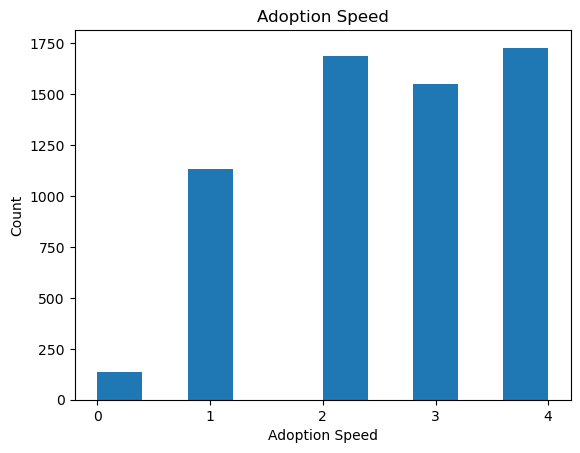

Text(0, 0.5, 'Age')

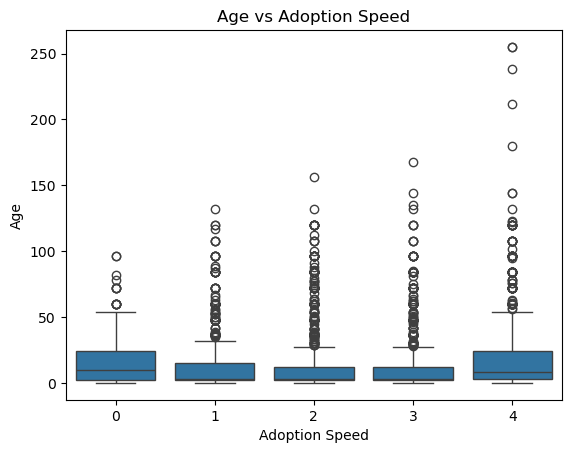

In [ ]:
##Visualizaitons

##histogram of adoption speed
##either 0,1,2,3, or 4
plt.hist(y)
plt.title('Adoption Speed')
plt.xlabel('Adoption Speed')
plt.ylabel('Count')
##adjust bins to only show 0,1,2,3,4
plt.xticks([0,1,2,3,4])
plt.show()
plt.clf()

##boxplot of age and adoptions speed
seaborn.boxplot(x='AdoptionSpeed', y='Age', data=df)
plt.title('Age vs Adoption Speed')
plt.xlabel('Adoption Speed')
plt.ylabel('Age in months')
